# Recommender Held-Out Evaluation Report

This notebook loads the final recommender evaluation for a single `run_id` and summarizes the **held-out test split**.

It is designed for the new recommender flow where:
- train/test are split by `dataset_index`
- final metrics come from the saved `evaluation_summary.json`
- missing recommender artifacts raise a clear error instead of silently falling back


In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)


In [2]:
# Edit these values to inspect another recommender run.
# RUN_ID = "federated-training-adult_income-20260426t223642651433+0000-logistic_regression-10clients-alpha0.3-seed42-e8df09baaba3"
# RUN_ID = "federated-training-adult_income-20260425t192946577949+0000-logistic_regression-10clients-alpha1.0-seed42-dba03a50b07b"
RUN_ID = "federated-training-adult_income-20260427t063710289874+0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2"
SELECTION_ID = "test__max-20__seed-42"
PERSONA = "lay"
RECOMMENDER_MODEL_KEY = "svm_rank_fedavg"
AGGREGATION_MODE_OVERRIDE = None


In [3]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing pyproject.toml")


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def parse_run_id(run_id: str) -> dict[str, object]:
    info: dict[str, object] = {"run_id": run_id}
    match = re.search(
        r"federated-training-(?P<dataset>.+?)-(?P<timestamp>\d{8}t\d{6}\d+\+\d+)-(?P<model>.+?)-(?P<num_clients>\d+)clients-alpha(?P<alpha>[^-]+)-seed(?P<seed>\d+)",
        run_id,
    )
    if not match:
        return info
    info.update(match.groupdict())
    info["num_clients"] = int(info["num_clients"])
    info["seed"] = int(info["seed"])
    try:
        info["alpha"] = float(info["alpha"])
    except ValueError:
        pass
    return info


def resolve_train_dir(
    repo_root: Path,
    run_id: str,
    selection_id: str,
    persona: str,
    model_key: str,
    aggregation_mode: str | None = None,
) -> Path:
    base_dir = (
        repo_root
        / "federated"
        / "runs"
        / run_id
        / "recommender_training"
        / selection_id
        / persona
        / model_key
    )
    plain_dir = base_dir / "plain"
    secure_dir = base_dir / "secure"
    if aggregation_mode is not None:
        normalized_mode = str(aggregation_mode).strip().lower()
        if normalized_mode not in {"plain", "secure"}:
            raise ValueError("aggregation_mode must be one of {'plain', 'secure'} when provided.")
        preferred_dir = plain_dir if normalized_mode == "plain" else secure_dir
        if preferred_dir.exists():
            return preferred_dir
        return base_dir
    existing_mode_dirs = [path for path in (plain_dir, secure_dir) if path.exists()]
    if len(existing_mode_dirs) == 1:
        return existing_mode_dirs[0]
    if len(existing_mode_dirs) > 1:
        raise FileExistsError(
            f"Run {run_id!r} has both plain and secure recommender artifacts. "
            "Set AGGREGATION_MODE_OVERRIDE to choose one explicitly."
        )
    return base_dir


def require_recommender_artifacts(train_dir: Path, run_id: str) -> dict[str, Path]:
    paths = {
        "evaluation_summary": train_dir / "evaluation_summary.json",
        "training_metadata": train_dir / "training_metadata.json",
        "model_artifact": train_dir / "model" / "global_recommender.npz",
    }
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        missing_text = ", ".join(missing)
        raise FileNotFoundError(
            f"Run {run_id!r} does not have completed recommender artifacts in {train_dir}. Missing: {missing_text}."
        )
    return paths


def format_value(value: object) -> str:
    if value is None:
        return "n/a"
    if isinstance(value, float):
        if math.isnan(value):
            return "n/a"
        return f"{value:.4f}"
    if isinstance(value, (list, tuple)):
        return ", ".join(str(item) for item in value)
    return str(value)


def make_metric_card(title: str, value: object, subtitle: str = "") -> str:
    subtitle_html = f"<div style='font-size:12px;color:#5f6368'>{subtitle}</div>" if subtitle else ""
    return (
        "<div style='padding:14px 16px;border:1px solid #d0d7de;border-radius:12px;"
        "background:#f8fafc;min-width:180px'>"
        f"<div style='font-size:12px;text-transform:uppercase;color:#5f6368;letter-spacing:0.04em'>{title}</div>"
        f"<div style='font-size:26px;font-weight:700;margin-top:4px'>{format_value(value)}</div>"
        f"{subtitle_html}"
        "</div>"
    )


def build_title_block(run_info: dict[str, object], training_metadata: dict, selection_id: str, persona: str) -> HTML:
    config = training_metadata.get("config", {})
    top_k = config.get("top_k", [])
    cards = [
        make_metric_card("Dataset", run_info.get("dataset")),
        make_metric_card("Model", run_info.get("model")),
        make_metric_card("Alpha", run_info.get("alpha")),
        make_metric_card("Clients", run_info.get("num_clients")),
        make_metric_card("K", top_k, "precision@K reported"),
        make_metric_card("Persona", persona),
        make_metric_card("Selection", selection_id),
        make_metric_card("Split", "held-out test", "final evaluation"),
    ]
    html = (
        "<div style='margin:8px 0 18px 0'>"
        "<div style='font-size:28px;font-weight:700;margin-bottom:6px'>Recommender Held-Out Test Results</div>"
        f"<div style='font-size:14px;color:#5f6368;margin-bottom:14px'><code>{run_info.get('run_id')}</code></div>"
        "<div style='display:flex;flex-wrap:wrap;gap:10px'>"
        + "".join(cards)
        + "</div></div>"
    )
    return HTML(html)


def safe_metric_columns(frame: pd.DataFrame) -> list[str]:
    columns = []
    for column in ["pearson", "precision_at_1", "precision_at_3", "precision_at_5"]:
        if column in frame.columns and frame[column].notna().any():
            columns.append(column)
    return columns


def summarize_metric(frame: pd.DataFrame, metric: str) -> dict[str, object]:
    valid = frame[["client_id", metric]].dropna()
    if valid.empty:
        return {
            "metric": metric,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "max": np.nan,
            "range": np.nan,
            "best_client": None,
            "worst_client": None,
        }
    best_idx = valid[metric].idxmax()
    worst_idx = valid[metric].idxmin()
    return {
        "metric": metric,
        "mean": valid[metric].mean(),
        "std": valid[metric].std(ddof=0),
        "min": valid[metric].min(),
        "max": valid[metric].max(),
        "range": valid[metric].max() - valid[metric].min(),
        "best_client": frame.loc[best_idx, "client_id"],
        "worst_client": frame.loc[worst_idx, "client_id"],
    }


def save_json(path: Path, payload: dict) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return path


def sanitize_segment(value: object) -> str:
    text = str(value).strip()
    cleaned = [char if (char.isalnum() or char in "._-") else "_" for char in text]
    normalized = "".join(cleaned).strip("._")
    return normalized or "value"


def aggregation_mode_label(training_metadata: dict) -> str:
    config = training_metadata.get("config", {})
    return "secure" if bool(config.get("secure_aggregation")) else "plain"


def resolve_notebook_output_dir(
    repo_root: Path,
    run_id: str,
    selection_id: str,
    persona: str,
    model_key: str,
    aggregation_mode: str,
) -> Path:
    output_root_name = (
        "recommender_evaluation_outputs_ranksvm_secure"
        if aggregation_mode == "secure"
        else "recommender_evaluation_outputs_ranksvm_no_secure"
    )
    return (
        repo_root
        / "notebooks"
        / output_root_name
        / sanitize_segment(run_id)
        / sanitize_segment(selection_id)
        / sanitize_segment(persona)
        / sanitize_segment(model_key)
        / sanitize_segment(aggregation_mode)
    )


def save_dataframe(frame: pd.DataFrame, output_dir: Path, stem: str, *, index: bool = False) -> dict[str, str]:
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / f"{stem}.csv"
    html_path = output_dir / f"{stem}.html"
    frame.to_csv(csv_path, index=index)
    frame.to_html(html_path, index=index)
    return {"csv": str(csv_path), "html": str(html_path)}


def save_figure(fig: plt.Figure, output_dir: Path, stem: str, *, dpi: int = 200) -> str:
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return str(path)


In [4]:
REPO_ROOT = find_repo_root()
TRAIN_DIR = resolve_train_dir(
    REPO_ROOT,
    RUN_ID,
    SELECTION_ID,
    PERSONA,
    RECOMMENDER_MODEL_KEY,
    AGGREGATION_MODE_OVERRIDE,
)
ARTIFACTS = require_recommender_artifacts(TRAIN_DIR, RUN_ID)

training_metadata = load_json(ARTIFACTS["training_metadata"])
evaluation_summary = load_json(ARTIFACTS["evaluation_summary"])
run_info = parse_run_id(RUN_ID)

if training_metadata.get("status") != "completed":
    raise ValueError(f"Recommender training for {RUN_ID!r} is not marked completed: {training_metadata.get('status')!r}")

if evaluation_summary.get("status") not in {None, "completed", "evaluated"}:
    raise ValueError(f"Unexpected evaluation status for {RUN_ID!r}: {evaluation_summary.get('status')!r}")

if training_metadata.get("eval_instance_count", 0) <= 0:
    raise ValueError(f"Run {RUN_ID!r} has no held-out evaluation instances recorded in training_metadata.json")

AGGREGATION_MODE = aggregation_mode_label(training_metadata)
OUTPUT_DIR = resolve_notebook_output_dir(
    REPO_ROOT,
    RUN_ID,
    SELECTION_ID,
    PERSONA,
    RECOMMENDER_MODEL_KEY,
    AGGREGATION_MODE,
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_EXPORT_MANIFEST = {
    "run_id": RUN_ID,
    "selection_id": SELECTION_ID,
    "persona": PERSONA,
    "model_key": RECOMMENDER_MODEL_KEY,
    "aggregation_mode": AGGREGATION_MODE,
    "train_dir": str(TRAIN_DIR),
    "output_dir": str(OUTPUT_DIR),
    "saved_tables": {},
    "saved_figures": {},
}
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

OUTPUT_DIR


PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/notebooks/recommender_evaluation_outputs_ranksvm_no_secure/federated-training-adult_income-20260427t063710289874_0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2/test__max-20__seed-42/lay/svm_rank_fedavg/plain')

In [5]:
display(build_title_block(run_info, training_metadata, SELECTION_ID, PERSONA))

aggregate = dict(evaluation_summary.get("aggregate", {}))
aggregate.pop("dataset_index", None)

run_overview = pd.DataFrame(
    {
        "run_id": [RUN_ID],
        "selection_id": [SELECTION_ID],
        "persona": [PERSONA],
        "model_key": [RECOMMENDER_MODEL_KEY],
        "aggregation_mode": [AGGREGATION_MODE],
        "alpha": [run_info.get("alpha")],
        "num_clients": [run_info.get("num_clients")],
        "top_k": [training_metadata.get("config", {}).get("top_k", [])],
        "rounds_completed": [training_metadata.get("rounds_completed")],
        "simulation_backend": [training_metadata.get("simulation_backend_actual")],
        "train_instances": [training_metadata.get("instance_count")],
        "test_instances": [training_metadata.get("eval_instance_count")],
        "train_candidates": [training_metadata.get("candidate_count")],
        "test_candidates": [training_metadata.get("eval_candidate_count")],
        "train_pairs_raw": [training_metadata.get("raw_pair_count")],
        "test_pairs_raw": [training_metadata.get("eval_raw_pair_count")],
        "train_pairs_augmented": [training_metadata.get("pair_count")],
        "test_pairs_augmented": [training_metadata.get("eval_pair_count")],
        "aggregate_pearson": [aggregate.get("pearson")],
        "aggregate_precision_at_1": [aggregate.get("precision_at_1")],
        "aggregate_precision_at_3": [aggregate.get("precision_at_3")],
        "aggregate_precision_at_5": [aggregate.get("precision_at_5")],
    }
)

NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["run_overview"] = save_dataframe(run_overview, OUTPUT_DIR, "run_overview")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

run_overview


,run_id,selection_id,persona,model_key,aggregation_mode,alpha,num_clients,top_k,rounds_completed,simulation_backend,train_instances,test_instances,train_candidates,test_candidates,train_pairs_raw,test_pairs_raw,train_pairs_augmented,test_pairs_augmented,aggregate_pearson,aggregate_precision_at_1,aggregate_precision_at_3,aggregate_precision_at_5
0,federated-training-adult_income-20260427t063710289874+0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2,test__max-20__seed-42,lay,svm_rank_fedavg,plain,0.3,15,"[1, 3, 5]",10,ray,240,60,11028,2766,255993,64338,511986,128676,0.83845,0.447372,0.608008,0.723063


In [6]:
client_eval_df = pd.DataFrame(evaluation_summary.get("clients", []))
if client_eval_df.empty:
    raise ValueError(f"Run {RUN_ID!r} has no per-client evaluation results in evaluation_summary.json")

client_train_df = pd.DataFrame(training_metadata.get("clients", []))
if not client_train_df.empty:
    client_train_df = client_train_df.rename(
        columns={
            "candidate_count": "train_candidate_count",
            "instance_count": "train_instance_count",
            "raw_pair_count": "train_pair_count_raw",
            "augmented_pair_count": "train_pair_count_augmented",
        }
    )
    keep_columns = [
        "client_id",
        "train_candidate_count",
        "train_instance_count",
        "train_pair_count_raw",
        "train_pair_count_augmented",
    ]
    client_df = client_eval_df.merge(client_train_df[keep_columns], on="client_id", how="left")
else:
    client_df = client_eval_df.copy()

metric_columns = safe_metric_columns(client_df)
client_df["average_metric_score"] = client_df[metric_columns].mean(axis=1, skipna=True)
client_df["test_pairs_per_instance"] = client_df["pair_count"] / client_df["instance_count"]
client_df["test_candidates_per_instance"] = client_df["candidate_count"] / client_df["instance_count"]

NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["client_metrics_full"] = save_dataframe(client_df, OUTPUT_DIR, "client_metrics_full")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

client_df[
    [
        "client_id",
        "instance_count",
        "candidate_count",
        "pair_count",
        *metric_columns,
        "average_metric_score",
        "train_instance_count",
        "train_candidate_count",
        "train_pair_count_raw",
    ]
].sort_values("average_metric_score", ascending=False)


,client_id,instance_count,candidate_count,pair_count,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,train_instance_count,train_candidate_count,train_pair_count_raw
12,client_012,4,158,3074,0.860765,1.000000,0.686836,0.819128,0.841682,16,593,10718
4,client_004,4,189,4502,0.888375,0.616615,0.666667,0.800000,0.742914,16,733,16675
11,client_011,4,143,2488,0.861646,0.493167,0.741827,0.802733,0.724843,16,572,9985
10,client_010,4,172,3621,0.882069,0.452914,0.674860,0.800000,0.702461,16,716,15856
8,client_008,4,194,4713,0.960542,0.404838,0.721833,0.682877,0.692523,16,872,23615
13,client_013,4,204,5305,0.851823,0.643544,0.501288,0.666730,0.665846,16,720,15951
5,client_005,4,186,4270,0.745312,0.453396,0.706089,0.755691,0.665122,16,805,20226
14,client_014,4,177,3832,0.730399,0.505219,0.752784,0.602296,0.647674,16,762,18123
9,client_009,4,208,5335,0.930448,0.238988,0.560200,0.847798,0.644358,16,833,21510
1,client_001,4,217,5839,0.796209,0.498544,0.603985,0.662682,0.640355,16,793,19533


In [7]:
aggregate_metric_frame = pd.DataFrame([summarize_metric(client_df, metric) for metric in metric_columns])
NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["aggregate_metric_summary"] = save_dataframe(aggregate_metric_frame, OUTPUT_DIR, "aggregate_metric_summary")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

aggregate_metric_frame


,metric,mean,std,min,max,range,best_client,worst_client
0,pearson,0.831281,0.085717,0.647134,0.960542,0.313409,client_008,client_003
1,precision_at_1,0.465131,0.187879,0.238988,1.000000,0.761012,client_012,client_009
2,precision_at_3,0.613559,0.095492,0.493525,0.752784,0.259258,client_014,client_003
3,precision_at_5,0.725433,0.098129,0.514682,0.859378,0.344696,client_007,client_006


In [8]:
top_clients = client_df.sort_values("average_metric_score", ascending=False).head(3)
bottom_clients = client_df.sort_values("average_metric_score", ascending=True).head(3)

NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["top_clients"] = save_dataframe(top_clients, OUTPUT_DIR, "top_clients")
NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["bottom_clients"] = save_dataframe(bottom_clients, OUTPUT_DIR, "bottom_clients")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

print("Top clients by average held-out score")
display(top_clients[["client_id", *metric_columns, "average_metric_score", "candidate_count", "pair_count"]].round(4))

print("Lowest clients by average held-out score")
display(bottom_clients[["client_id", *metric_columns, "average_metric_score", "candidate_count", "pair_count"]].round(4))


Top clients by average held-out score


,client_id,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,candidate_count,pair_count
12,client_012,0.8608,1.0000,0.6868,0.8191,0.8417,158,3074
4,client_004,0.8884,0.6166,0.6667,0.8000,0.7429,189,4502
11,client_011,0.8616,0.4932,0.7418,0.8027,0.7248,143,2488


Lowest clients by average held-out score


,client_id,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,candidate_count,pair_count
3,client_003,0.6471,0.2665,0.4935,0.7039,0.5278,151,2780
2,client_002,0.9401,0.2544,0.5029,0.6054,0.5757,222,6054
6,client_006,0.8548,0.4378,0.5036,0.5147,0.5777,174,3746


In [9]:
summary_columns = [
    "client_id",
    "instance_count",
    "candidate_count",
    "pair_count",
    *metric_columns,
    "average_metric_score",
    "test_candidates_per_instance",
    "test_pairs_per_instance",
    "train_instance_count",
    "train_candidate_count",
    "train_pair_count_raw",
]

client_report = client_df[summary_columns].sort_values("average_metric_score", ascending=False)
NOTEBOOK_EXPORT_MANIFEST["saved_tables"]["client_report"] = save_dataframe(client_report, OUTPUT_DIR, "client_report")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)

client_report.round(4)


,client_id,instance_count,candidate_count,pair_count,pearson,precision_at_1,precision_at_3,precision_at_5,average_metric_score,test_candidates_per_instance,test_pairs_per_instance,train_instance_count,train_candidate_count,train_pair_count_raw
12,client_012,4,158,3074,0.8608,1.0000,0.6868,0.8191,0.8417,39.50,768.50,16,593,10718
4,client_004,4,189,4502,0.8884,0.6166,0.6667,0.8000,0.7429,47.25,1125.50,16,733,16675
11,client_011,4,143,2488,0.8616,0.4932,0.7418,0.8027,0.7248,35.75,622.00,16,572,9985
10,client_010,4,172,3621,0.8821,0.4529,0.6749,0.8000,0.7025,43.00,905.25,16,716,15856
8,client_008,4,194,4713,0.9605,0.4048,0.7218,0.6829,0.6925,48.50,1178.25,16,872,23615
13,client_013,4,204,5305,0.8518,0.6435,0.5013,0.6667,0.6658,51.00,1326.25,16,720,15951
5,client_005,4,186,4270,0.7453,0.4534,0.7061,0.7557,0.6651,46.50,1067.50,16,805,20226
14,client_014,4,177,3832,0.7304,0.5052,0.7528,0.6023,0.6477,44.25,958.00,16,762,18123
9,client_009,4,208,5335,0.9304,0.2390,0.5602,0.8478,0.6444,52.00,1333.75,16,833,21510
1,client_001,4,217,5839,0.7962,0.4985,0.6040,0.6627,0.6404,54.25,1459.75,16,793,19533


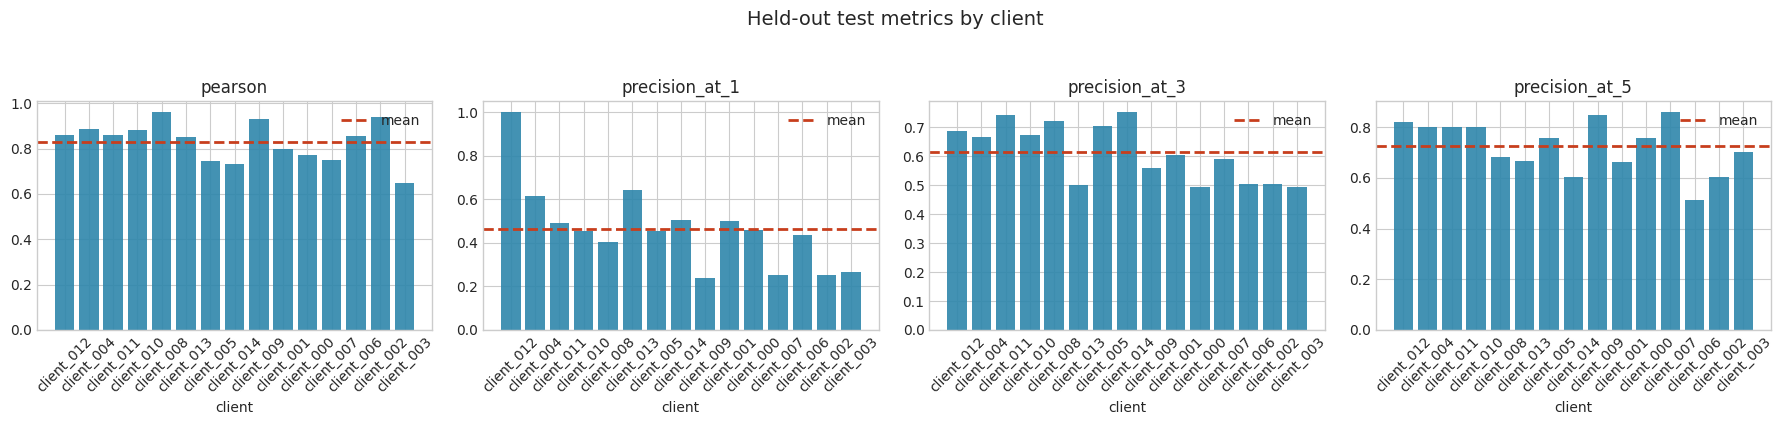

In [10]:
fig, axes = plt.subplots(1, len(metric_columns), figsize=(4.5 * len(metric_columns), 4), sharey=False)
if len(metric_columns) == 1:
    axes = [axes]

ordered = client_df.sort_values("average_metric_score", ascending=False)
for ax, metric in zip(axes, metric_columns):
    ax.bar(ordered["client_id"], ordered[metric], color="#2E86AB", alpha=0.9)
    ax.axhline(ordered[metric].mean(), color="#C73E1D", linestyle="--", linewidth=2, label="mean")
    ax.set_title(metric)
    ax.set_xlabel("client")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

plt.suptitle("Held-out test metrics by client", y=1.05, fontsize=14)
plt.tight_layout()
NOTEBOOK_EXPORT_MANIFEST["saved_figures"]["metrics_by_client"] = save_figure(fig, OUTPUT_DIR, "metrics_by_client")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)
plt.show()


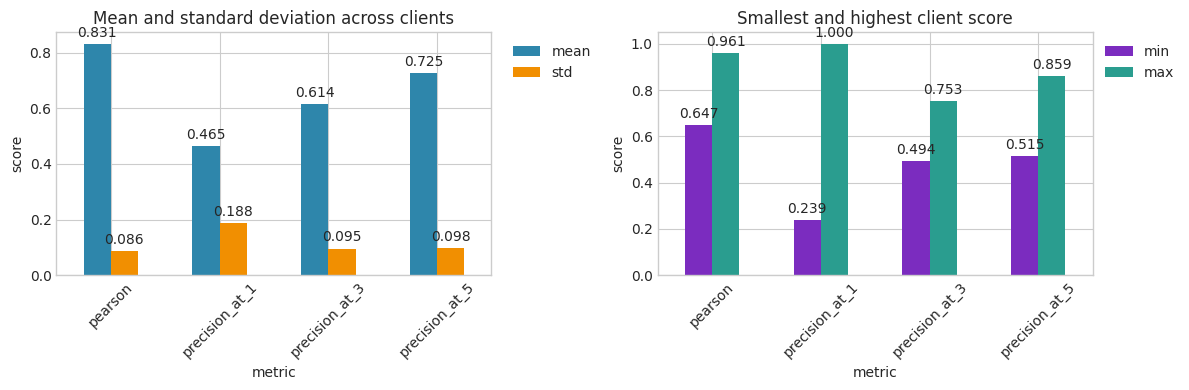

In [11]:
def annotate_bars(ax, fmt="{:.3f}", rotation=0, fontsize=10):
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            if pd.isna(height):
                labels.append("")
            else:
                labels.append(fmt.format(height))
        ax.bar_label(container, labels=labels, padding=3, rotation=rotation, fontsize=fontsize)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

aggregate_metric_frame.set_index("metric")[["mean", "std"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#2E86AB", "#F18F01"],
    title="Mean and standard deviation across clients",
)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("score")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
annotate_bars(axes[0])

aggregate_metric_frame.set_index("metric")[["min", "max"]].plot(
    kind="bar",
    ax=axes[1],
    color=["#7B2CBF", "#2A9D8F"],
    title="Smallest and highest client score",
)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("score")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
annotate_bars(axes[1])

plt.tight_layout()
NOTEBOOK_EXPORT_MANIFEST["saved_figures"]["mean_metrics"] = save_figure(fig, OUTPUT_DIR, "mean_metrics")
save_json(OUTPUT_DIR / "export_manifest.json", NOTEBOOK_EXPORT_MANIFEST)
plt.show()

## Notes

- This notebook reads the **final post-training** recommender evaluation from `evaluation_summary.json`.
- The reported metrics are for the **held-out test split** only.
- If a `run_id` does not have completed recommender artifacts, the loading cell raises a clear error with the missing files.


## Comparison

This section compares exported recommender evaluation runs side by side. The registry below maps human-readable experiment labels to notebook output roots, so new variants such as `clustered_k_svm_secure` can be added later without rewriting the plotting logic.


,config,mean,std,model_key,aggregation_mode
0,svm_secure,0.6381,0.1180,svm_rank_fedavg,secure
1,svm_no_secure,0.6481,0.1171,svm_rank_fedavg,plain


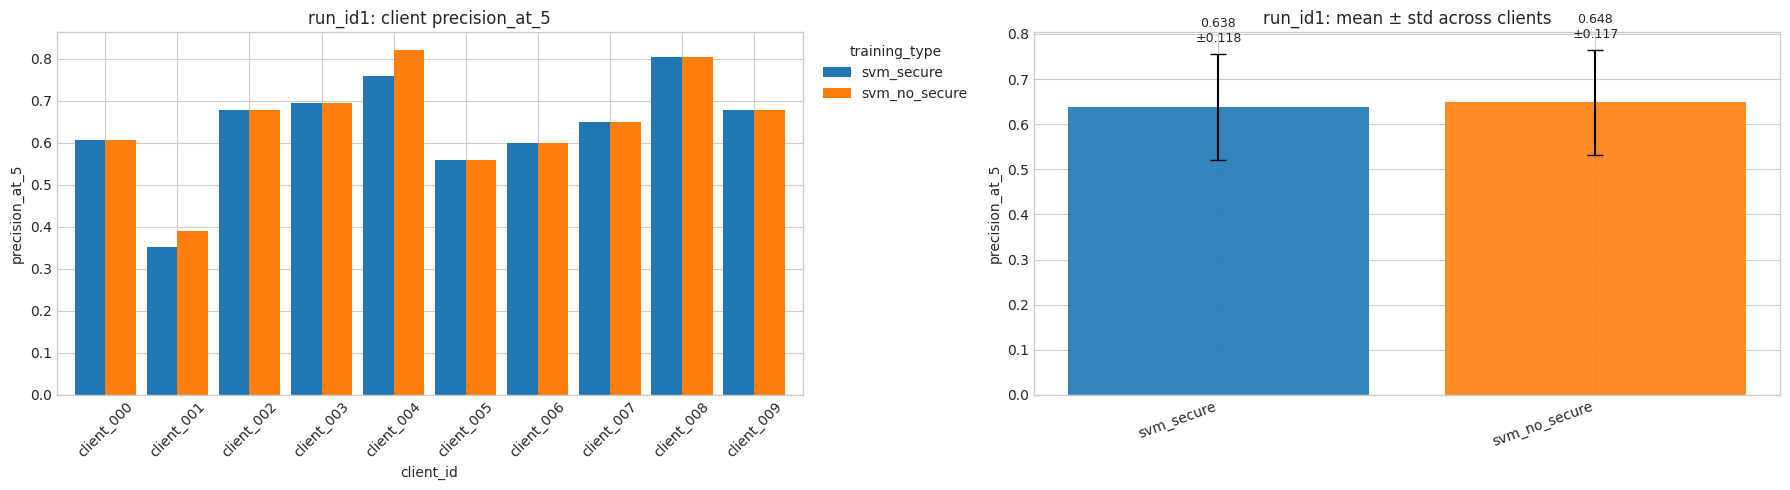

,config,mean,std,model_key,aggregation_mode
0,svm_secure,0.6362,0.2046,svm_rank_fedavg,secure
1,svm_no_secure,0.6324,0.2092,svm_rank_fedavg,plain


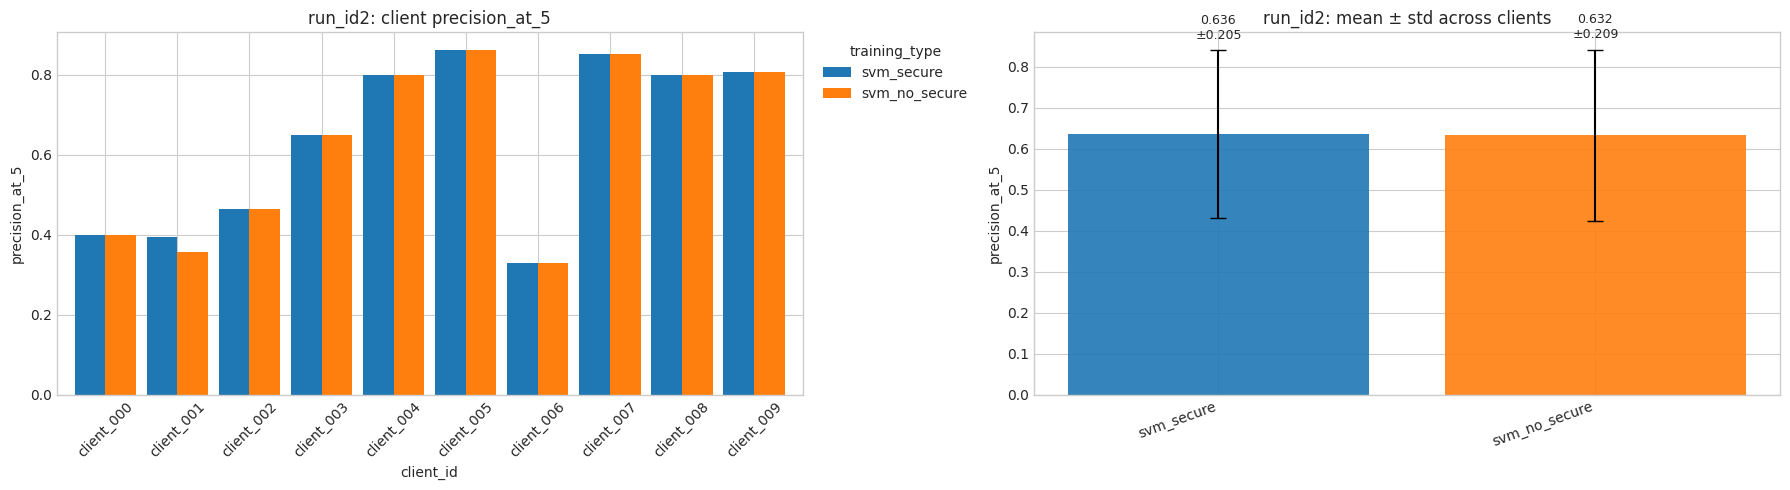

,config,mean,std,model_key,aggregation_mode
0,svm_secure,0.7141,0.0945,svm_rank_fedavg,secure
1,svm_no_secure,0.7254,0.0981,svm_rank_fedavg,plain


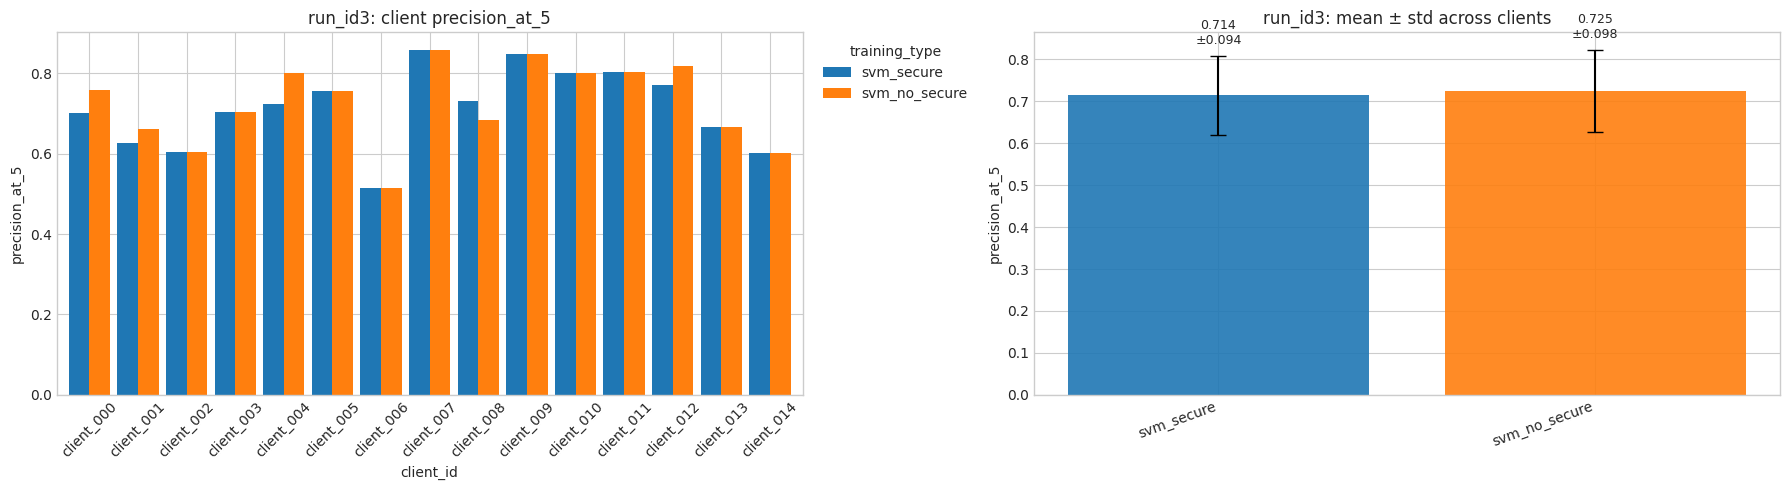

In [12]:
COMPARISON_METRIC = "precision_at_5"

COMPARISON_OUTPUT_ROOTS = {
    # "lr_pairwise_nosecure": {
    #     "path": REPO_ROOT / "notebooks" / "recommender_evaluation_outputs",
    #     "expected_model_key": "pairwise_logistic_fedavg",
    #     "expected_aggregation_mode": "plain",
    # },
    # "lr_pairwise_secure": {
    #     "path": REPO_ROOT / "notebooks" / "recommender_evaluation_outputs_secure",
    #     "expected_model_key": "pairwise_logistic_fedavg",
    #     "expected_aggregation_mode": "secure",
    # },
    "svm_secure": {
        "path": REPO_ROOT / "notebooks" / "recommender_evaluation_outputs_ranksvm_secure",
        "expected_model_key": "svm_rank_fedavg",
        "expected_aggregation_mode": "secure",
    },
    "svm_no_secure": {
        "path": REPO_ROOT / "notebooks" / "recommender_evaluation_outputs_ranksvm_no_secure",
        "expected_model_key": "svm_rank_fedavg",
        "expected_aggregation_mode": "plain",
    },
}


def _comparison_root_labels() -> list[str]:
    return list(COMPARISON_OUTPUT_ROOTS.keys())


def _extract_metric_row(frame: pd.DataFrame, metric: str) -> dict[str, float]:
    metric_row = frame.loc[frame["metric"] == metric]
    if metric_row.empty:
        return {"mean": np.nan, "std": np.nan}
    row = metric_row.iloc[0]
    return {
        "mean": float(row.get("mean", np.nan)),
        "std": float(row.get("std", np.nan)),
    }


def load_comparison_exports(config_label: str, config: dict[str, object]) -> list[dict[str, object]]:
    root = Path(config["path"])
    if not root.exists():
        return []

    entries: list[dict[str, object]] = []
    for manifest_path in sorted(root.rglob("export_manifest.json")):
        payload = load_json(manifest_path)
        if config.get("expected_model_key") and payload.get("model_key") != config["expected_model_key"]:
            continue
        if (
            config.get("expected_aggregation_mode")
            and payload.get("aggregation_mode") != config["expected_aggregation_mode"]
        ):
            continue

        saved_tables = payload.get("saved_tables", {})
        client_report_meta = saved_tables.get("client_report") or saved_tables.get("client_metrics_full")
        aggregate_meta = saved_tables.get("aggregate_metric_summary")
        if not client_report_meta or not aggregate_meta:
            continue

        client_csv = Path(client_report_meta["csv"])
        aggregate_csv = Path(aggregate_meta["csv"])
        if not client_csv.exists() or not aggregate_csv.exists():
            continue

        client_df = pd.read_csv(client_csv)
        aggregate_df = pd.read_csv(aggregate_csv)
        if COMPARISON_METRIC not in client_df.columns:
            continue

        relative_parts = manifest_path.relative_to(root).parts
        run_folder = relative_parts[0]
        metric_stats = _extract_metric_row(aggregate_df, COMPARISON_METRIC)
        entries.append(
            {
                "config_label": config_label,
                "root_path": root,
                "run_folder": run_folder,
                "run_id": payload.get("run_id"),
                "selection_id": payload.get("selection_id"),
                "persona": payload.get("persona"),
                "model_key": payload.get("model_key"),
                "aggregation_mode": payload.get("aggregation_mode"),
                "manifest_path": manifest_path,
                "client_df": client_df,
                "aggregate_df": aggregate_df,
                "metric_mean": metric_stats["mean"],
                "metric_std": metric_stats["std"],
            }
        )

    return entries


comparison_entries: list[dict[str, object]] = []
for comparison_label, comparison_config in COMPARISON_OUTPUT_ROOTS.items():
    comparison_entries.extend(load_comparison_exports(comparison_label, comparison_config))

if not comparison_entries:
    raise ValueError("No comparison exports were found under the configured notebook output roots.")

comparison_run_folders = sorted({entry["run_folder"] for entry in comparison_entries})
comparison_run_alias_map = {
    run_folder: f"run_id{index + 1}"
    for index, run_folder in enumerate(comparison_run_folders)
}
for entry in comparison_entries:
    entry["run_alias"] = comparison_run_alias_map[entry["run_folder"]]

comparison_overview_rows: list[dict[str, object]] = []
for run_folder in comparison_run_folders:
    run_entries = [entry for entry in comparison_entries if entry["run_folder"] == run_folder]
    by_label = {entry["config_label"]: entry for entry in run_entries}
    representative = run_entries[0]
    row: dict[str, object] = {
        "run_alias": comparison_run_alias_map[run_folder],
        "run_folder": run_folder,
        "run_id": representative.get("run_id"),
        "selection_id": representative.get("selection_id"),
        "persona": representative.get("persona"),
    }
    for comparison_label in _comparison_root_labels():
        row[comparison_label] = comparison_label in by_label
    comparison_overview_rows.append(row)

comparison_overview = pd.DataFrame(comparison_overview_rows)
comparison_overview

comparison_colors = {
    label: color
    for label, color in zip(
        _comparison_root_labels(),
        ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"],
    )
}

for run_folder in comparison_run_folders:
    run_entries = [entry for entry in comparison_entries if entry["run_folder"] == run_folder]
    run_entries = sorted(run_entries, key=lambda entry: _comparison_root_labels().index(entry["config_label"]))
    run_alias = comparison_run_alias_map[run_folder]
    display(
        HTML(
            f"<h3 style='margin-top:20px'>{run_alias}</h3>"
            f"<div style='margin-bottom:10px'><code>{run_entries[0]['run_id']}</code></div>"
        )
    )

    client_metric_wide: pd.DataFrame | None = None
    summary_rows: list[dict[str, object]] = []
    for entry in run_entries:
        label = entry["config_label"]
        client_slice = entry["client_df"][["client_id", COMPARISON_METRIC]].copy()
        client_slice = client_slice.rename(columns={COMPARISON_METRIC: label})
        if client_metric_wide is None:
            client_metric_wide = client_slice
        else:
            client_metric_wide = client_metric_wide.merge(client_slice, on="client_id", how="outer")

        summary_rows.append(
            {
                "config": label,
                "mean": entry["metric_mean"],
                "std": entry["metric_std"],
                "model_key": entry["model_key"],
                "aggregation_mode": entry["aggregation_mode"],
            }
        )

    if client_metric_wide is None:
        continue

    client_metric_wide = client_metric_wide.sort_values("client_id").reset_index(drop=True)
    summary_frame = pd.DataFrame(summary_rows)
    display(summary_frame.round(4))

    ordered_labels = [entry["config_label"] for entry in run_entries]
    plot_colors = [comparison_colors.get(label, "#333333") for label in ordered_labels]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    client_metric_wide.set_index("client_id")[ordered_labels].plot(
        kind="bar",
        ax=axes[0],
        color=plot_colors,
        width=0.85,
    )
    axes[0].set_title(f"{run_alias}: client {COMPARISON_METRIC}")
    axes[0].set_xlabel("client_id")
    axes[0].set_ylabel(COMPARISON_METRIC)
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend(title="training_type", loc="upper left", bbox_to_anchor=(1.01, 1.0))

    mean_positions = np.arange(len(summary_frame))
    bars = axes[1].bar(
        mean_positions,
        summary_frame["mean"],
        yerr=summary_frame["std"],
        capsize=6,
        color=plot_colors,
        alpha=0.9,
    )
    axes[1].set_xticks(mean_positions)
    axes[1].set_xticklabels(summary_frame["config"], rotation=20, ha="right")
    axes[1].set_ylabel(COMPARISON_METRIC)
    axes[1].set_title(f"{run_alias}: mean ± std across clients")
    for bar, mean_value, std_value in zip(bars, summary_frame["mean"], summary_frame["std"], strict=True):
        if pd.isna(mean_value):
            continue
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            mean_value + (0.02 if pd.isna(std_value) else std_value + 0.02),
            f"{mean_value:.3f}\n±{0.0 if pd.isna(std_value) else std_value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
